# 🔍 EDA + Data Cleaning Pipeline
### Order: Load → EDA → Cleaning → Save Clean Data

##  Step 0 — Install Libraries

In [11]:
!pip install pandas numpy matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


##  Step 1 — Imports

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print(' Libraries imported!')

 Libraries imported!


##  Step 2 — Configuration

In [14]:
DATA_PATH    = r'C:\Users\hp\OneDrive\Desktop\ml_model_training\clean_numeric_dataset.parquet'
LABEL_COLUMN = 'label'

print(' Config set!')

 Config set!


##  Step 3 — Data Loading

In [16]:
df = pd.read_parquet(DATA_PATH)
print(f'Shape      : {df.shape}')
print(f'Rows       : {df.shape[0]:,}')
print(f'Columns    : {df.shape[1]}')
print(f'\nColumn names:')
print(df.columns.tolist())
print(f'\nFirst 5 rows:')
df.head()

Shape      : (2157943, 78)
Rows       : 2,157,943
Columns    : 78

Column names:
['protocol', 'flow_duration', 'total_fwd_packets', 'total_backward_packets', 'fwd_packets_length_total', 'bwd_packets_length_total', 'fwd_packet_length_max', 'fwd_packet_length_min', 'fwd_packet_length_mean', 'fwd_packet_length_std', 'bwd_packet_length_max', 'bwd_packet_length_min', 'bwd_packet_length_mean', 'bwd_packet_length_std', 'flow_bytes/s', 'flow_packets/s', 'flow_iat_mean', 'flow_iat_std', 'flow_iat_max', 'flow_iat_min', 'fwd_iat_total', 'fwd_iat_mean', 'fwd_iat_std', 'fwd_iat_max', 'fwd_iat_min', 'bwd_iat_total', 'bwd_iat_mean', 'bwd_iat_std', 'bwd_iat_max', 'bwd_iat_min', 'fwd_psh_flags', 'bwd_psh_flags', 'fwd_urg_flags', 'bwd_urg_flags', 'fwd_header_length', 'bwd_header_length', 'fwd_packets/s', 'bwd_packets/s', 'packet_length_min', 'packet_length_max', 'packet_length_mean', 'packet_length_std', 'packet_length_variance', 'fin_flag_count', 'syn_flag_count', 'rst_flag_count', 'psh_flag_count', 'a

,protocol,flow_duration,total_fwd_packets,total_backward_packets,fwd_packets_length_total,bwd_packets_length_total,fwd_packet_length_max,fwd_packet_length_min,fwd_packet_length_mean,fwd_packet_length_std,...,fwd_seg_size_min,active_mean,active_std,active_max,active_min,idle_mean,idle_std,idle_max,idle_min,label
0,6,4,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
1,6,1,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
2,6,3,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
3,6,1,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
4,6,609,7,4,484,414,233,0,69.14286,111.967896,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign


---
#  EDA — Exploratory Data Analysis


## 📊 EDA Step 1 — Basic Info (Shape, Types, Missing)

In [6]:
print('='*55)
print('  BASIC INFO')
print('='*55)
print(f'Shape      : {df.shape}')
print(f'Total rows : {df.shape[0]:,}')
print(f'Columns    : {df.shape[1]}')

print('\nData Types:')
print(df.dtypes.value_counts())

print('\nMissing Values:')
missing = df.isnull().sum()
missing = missing[missing > 0]
if len(missing) == 0:
    print('  no missing values ')
else:
    print(missing)

print(f'\nDuplicate rows: {df.duplicated().sum():,}')
print(f'Memory usage  : {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB')

  BASIC INFO
Shape      : (2157943, 78)
Total rows : 2,157,943
Columns    : 78

Data Types:
int32      26
float32    22
int8       19
int16       7
float64     2
int64       1
object      1
Name: count, dtype: int64

Missing Values:
  no missing values 

Duplicate rows: 64,753
Memory usage  : 624.9 MB


##  EDA Step 2 — Class Distribution

In [19]:
vc = df[LABEL_COLUMN].value_counts()
pct = df[LABEL_COLUMN].value_counts(normalize=True) * 100

print(pd.DataFrame({'Count': vc, 'Percentage': pct}))

              Count  Percentage
label                          
Benign      1823641   84.508303
DoS          193745    8.978226
DDoS         128014    5.932223
BruteForce     9150    0.424015
PortScan       1956    0.090642
Bot            1437    0.066591


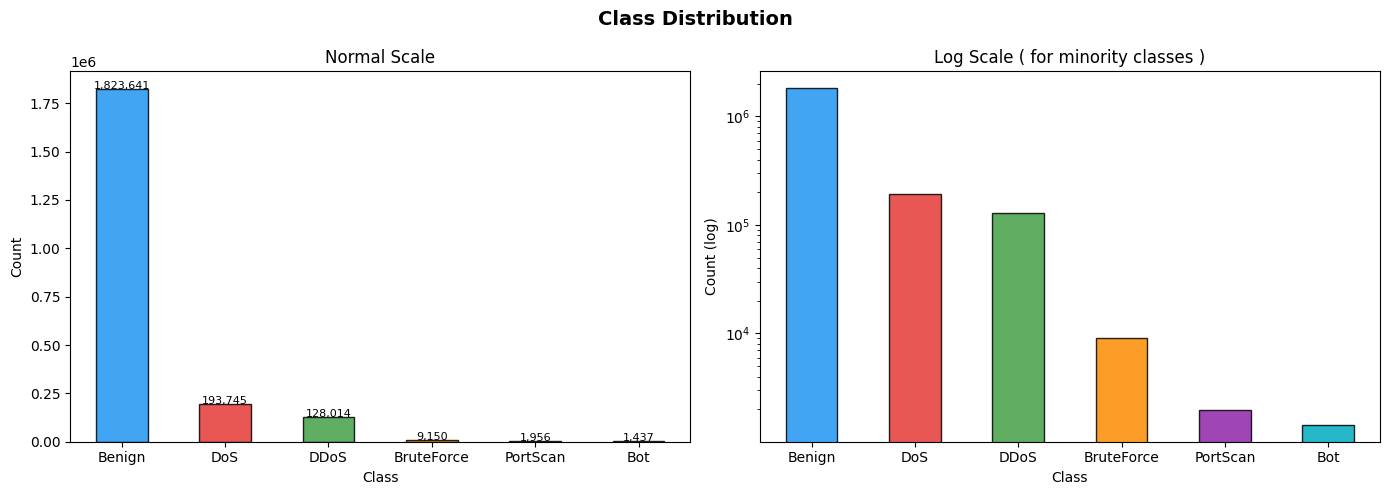

 Saved: eda_class_distribution.png


In [ ]:
# Class Distribution Charts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Class Distribution', fontsize=14, fontweight='bold')

colors = ['#2196F3','#E53935','#43A047','#FB8C00','#8E24AA','#00ACC1']

# Normal scale
vc.plot(kind='bar', ax=axes[0], color=colors[:len(vc)], edgecolor='black', alpha=0.85)
axes[0].set_title('Normal Scale')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
for bar, cnt in zip(axes[0].patches, vc.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1000,
                 f'{cnt:,}', ha='center', fontsize=8)

# Log scale — minority classes 
vc.plot(kind='bar', ax=axes[1], color=colors[:len(vc)], edgecolor='black', alpha=0.85)
axes[1].set_yscale('log')
axes[1].set_title('Log Scale ( for minority classes )')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count (log)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: eda_class_distribution.png')

In [21]:
print('='*75)
print('  UNIQUE vs DUPLICATE PATTERNS PER CLASS')
print('='*75)

print(f'  {"Class":<15} {"Total":>12} {"Unique":>12} {"Duplicate":>12} {"Dup%":>8} {"Quality":>10}')
print(f'  {"-"*75}')

dup_data = []

for cls in sorted(df[LABEL_COLUMN].unique()):
    subset    = df[df[LABEL_COLUMN]==cls]
    total     = len(subset)
    unique    = len(subset.drop_duplicates())
    duplicate = total - unique
    dup_pct   = duplicate/total*100
    quality   = 'Good' if dup_pct < 30 else 'Check' if dup_pct < 70 else 'Bad'

    dup_data.append({
        'class':cls,
        'total':total,
        'unique':unique,
        'duplicate':duplicate,
        'dup_pct':dup_pct
    })

    print(f'  {cls:<15} {total:>12,} {unique:>12,} {duplicate:>12,} {dup_pct:>7.1f}% {quality:>10}')

dup_df = pd.DataFrame(dup_data)

  UNIQUE vs DUPLICATE PATTERNS PER CLASS
  Class                  Total       Unique    Duplicate     Dup%    Quality
  ---------------------------------------------------------------------------
  Benign             1,823,641    1,758,888       64,753     3.6%       Good
  Bot                    1,437        1,437            0     0.0%       Good
  BruteForce             9,150        9,150            0     0.0%       Good
  DDoS                 128,014      128,014            0     0.0%       Good
  DoS                  193,745      193,745            0     0.0%       Good
  PortScan               1,956        1,956            0     0.0%       Good


##  EDA Step 3 — Duplicate Patterns Per Class

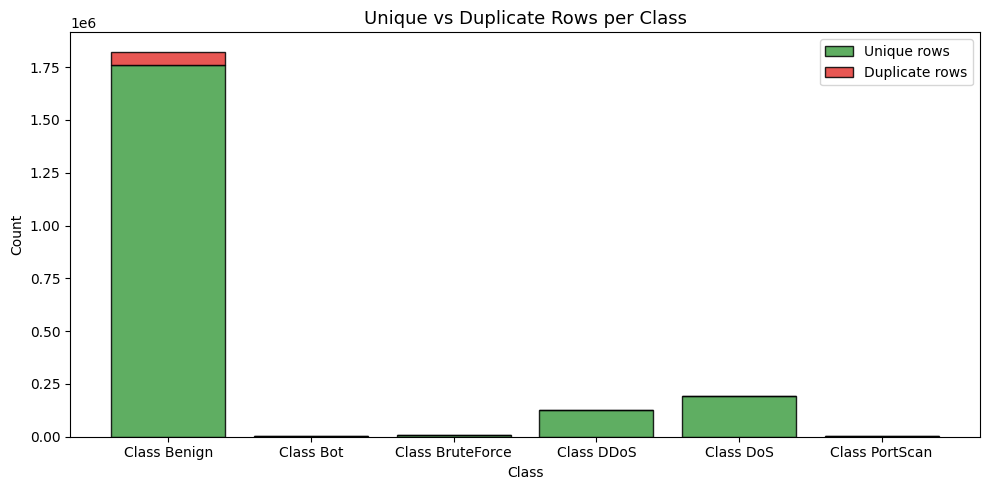

 Saved: eda_duplicates.png


In [22]:
# Unique vs Duplicate chart
fig, ax = plt.subplots(figsize=(10, 5))
classes = dup_df['class'].astype(str)
x = range(len(classes))
ax.bar(x, dup_df['unique'],    label='Unique rows',    color='#43A047', edgecolor='black', alpha=0.85)
ax.bar(x, dup_df['duplicate'], label='Duplicate rows', color='#E53935', edgecolor='black', alpha=0.85,
       bottom=dup_df['unique'])
ax.set_title('Unique vs Duplicate Rows per Class', fontsize=13)
ax.set_xlabel('Class')
ax.set_ylabel('Count')
ax.set_xticks(list(x))
ax.set_xticklabels([f'Class {c}' for c in classes])
ax.legend()
plt.tight_layout()
plt.savefig('eda_duplicates.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: eda_duplicates.png')

##  EDA Step 4 — Minority Classes Detail

In [24]:

small_classes = df[LABEL_COLUMN].value_counts().tail(3).index.tolist()

for cls in small_classes:
    subset = df[df[LABEL_COLUMN]==cls]
    print('='*60)
    print(f'  CLASS {cls} — {len(subset):,} rows')
    print('='*60)

    # Top repeated patterns
    print(f'  Top 5 repeated patterns:')
    cols = df.columns[:5].tolist()
    if LABEL_COLUMN in cols:
        cols.remove(LABEL_COLUMN)
    top_pat = subset[cols].value_counts().head(5)
    print(top_pat.to_string())

    # Unique rows
    total  = len(subset)
    unique = len(subset.drop_duplicates())
    print(f'\n  Unique rows    : {unique:,} / {total:,}')
    print(f'  Duplicate rows : {total-unique:,} ({(total-unique)/total*100:.1f}%)')
    print()

  CLASS BruteForce — 9,150 rows
  Top 5 repeated patterns:
protocol  flow_duration  total_fwd_packets  total_backward_packets  fwd_packets_length_total
6         224            2                  1                       14                          38
          223            2                  1                       14                          37
          231            2                  1                       14                          37
          245            2                  1                       14                          36
          221            2                  1                       14                          34

  Unique rows    : 9,150 / 9,150
  Duplicate rows : 0 (0.0%)

  CLASS PortScan — 1,956 rows
  Top 5 repeated patterns:
protocol  flow_duration  total_fwd_packets  total_backward_packets  fwd_packets_length_total
6         708            3                  1                       0                           6
          546            2                

##  EDA Step 5 — Negative Values Check

In [26]:
print('='*55)
print('  NEGATIVE VALUES CHECK')
print('='*55)

num_cols = df.select_dtypes(include='number').columns.tolist()
num_cols = [c for c in num_cols if c != LABEL_COLUMN]

neg = (df[num_cols] < 0).sum()
neg = neg[neg > 0]

if len(neg) == 0:
    print('  no negative value!')
else:
    print(f'   {len(neg)} features ')
    print(f'  {"Feature":<35} {"Negative Count":>15} {"% of rows":>10}')
    print(f'  {"-"*62}')
    for feat, cnt in neg.sort_values(ascending=False).items():
        pct = cnt/len(df)*100
        print(f'  {feat:<35} {cnt:>15,} {pct:>9.2f}%')

  NEGATIVE VALUES CHECK
   12 features 
  Feature                              Negative Count  % of rows
  --------------------------------------------------------------
  init_bwd_win_bytes                        1,087,087     50.38%
  init_fwd_win_bytes                          871,398     40.38%
  flow_iat_min                                  2,540      0.12%
  flow_duration                                    77      0.00%
  flow_packets/s                                   77      0.00%
  flow_iat_mean                                    77      0.00%
  flow_iat_max                                     77      0.00%
  flow_bytes/s                                     49      0.00%
  fwd_seg_size_min                                 35      0.00%
  fwd_header_length                                35      0.00%
  bwd_header_length                                22      0.00%
  fwd_iat_min                                      17      0.00%


##  EDA Step 6 — Outliers Check

\ FULL OUTLIER TABLE
                 Feature  Outliers  % Rows
           bwd_packets/s    229641   22.96
          flow_packets/s    225523   22.55
           fwd_packets/s    224056   22.41
            flow_bytes/s    223885   22.39
             bwd_iat_max    218945   21.89
           bwd_iat_total    217202   21.72
            bwd_iat_mean    215870   21.59
             fwd_iat_min    213951   21.40
           flow_duration    204446   20.44
            flow_iat_min    204430   20.44
            fwd_iat_mean    202035   20.20
           fwd_iat_total    200501   20.05
             bwd_iat_std    196317   19.63
           flow_iat_mean    178162   17.82
  packet_length_variance    169026   16.90
    avg_bwd_segment_size    164376   16.44
  bwd_packet_length_mean    164376   16.44
bwd_packets_length_total    161983   16.20
       subflow_bwd_bytes    161983   16.20
             fwd_iat_std    161873   16.19
      packet_length_mean    157689   15.77
         avg_packet_size    15694

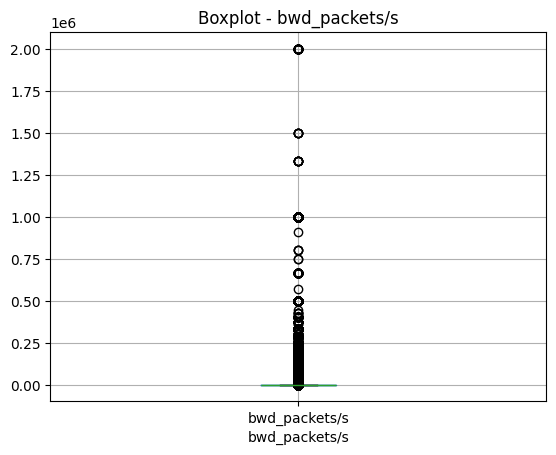

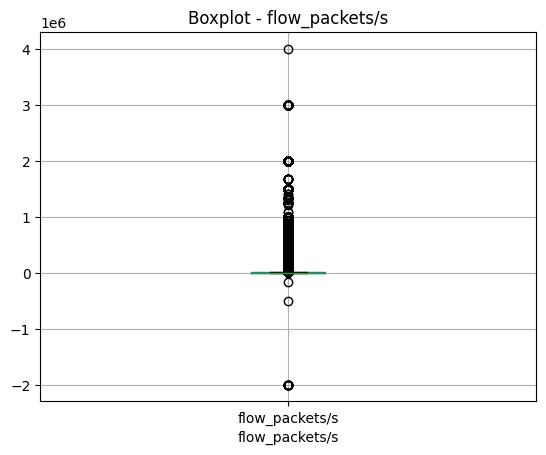

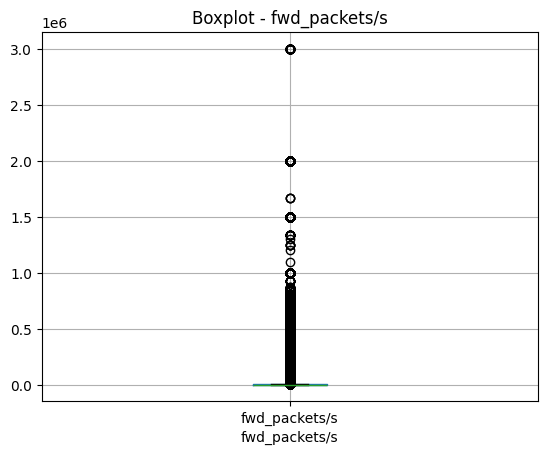

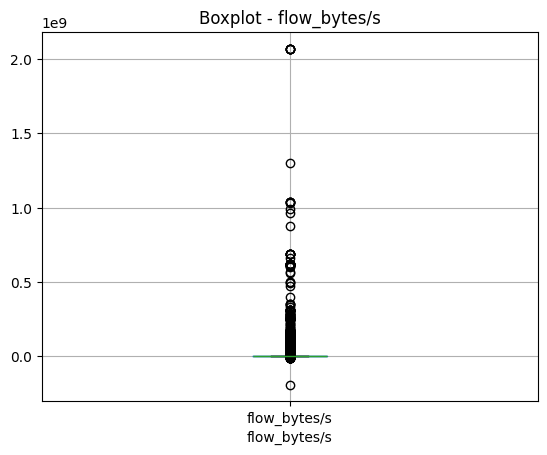

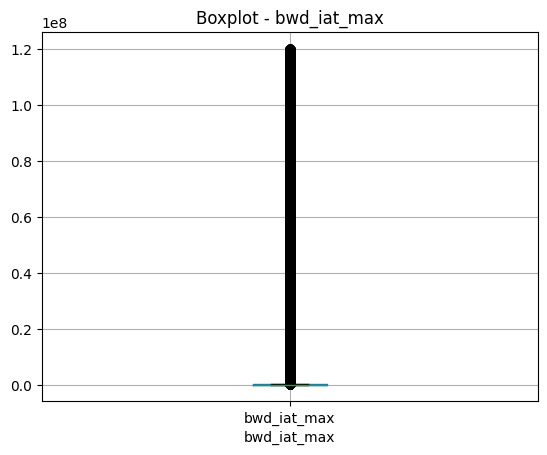

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

LABEL_COLUMN = 'label'
SAMPLE_SIZE = 1000000
TOP_N = 5   # kitne top features ka plot chahiye

# ==============================
# SAMPLE DATA
# ==============================
df_sample = df.sample(SAMPLE_SIZE, random_state=42)

# ==============================
# NUMERIC COLUMNS
# ==============================
num_cols = df_sample.select_dtypes(include='number').columns.tolist()
num_cols = [c for c in num_cols if c != LABEL_COLUMN]

# ==============================
# STEP 1: OUTLIER TABLE (ALL FEATURES)
# ==============================
results = []

for col in num_cols:
    Q1 = df_sample[col].quantile(0.25)
    Q3 = df_sample[col].quantile(0.75)
    IQR = Q3 - Q1

    if IQR == 0:
        out_count = 0
    else:
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        out_count = ((df_sample[col] < lower) | (df_sample[col] > upper)).sum()

    pct = (out_count / len(df_sample)) * 100

    results.append([col, out_count, round(pct, 2)])

# create table
outlier_df = pd.DataFrame(results, columns=['Feature', 'Outliers', '% Rows'])

# sort by outliers
outlier_df = outlier_df.sort_values(by='Outliers', ascending=False)

# print full table
print("\ FULL OUTLIER TABLE")
print(outlier_df.to_string(index=False))

# ==============================
# STEP 2: TOP FEATURES
# ==============================
top_df = outlier_df.head(TOP_N)

print(f" TOP {TOP_N} FEATURES WITH MOST OUTLIERS")
print(top_df)

# ==============================
# STEP 3: PLOT ONLY TOP FEATURES
# ==============================
print(" Showing Boxplots for Top Features...")

for col in top_df['Feature']:
    plt.figure()
    df_sample.boxplot(column=col)
    plt.title(f'Boxplot - {col}')
    plt.xlabel(col)
    plt.show()

In [44]:
col = 'flow_bytes/s'

Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(lower, upper)

# print(df[(df[col] < lower) | (df[col] > upper)].head())

-44146.122822856225 73895.08110171373


In [45]:
col = 'flow_bytes/s'

outliers = df[(df[col] < lower) | (df[col] > upper)]

print(outliers[[col]].head())

   flow_bytes/s
0  3.000000e+06
1  1.200000e+07
2  4.000000e+06
3  1.200000e+07
4  1.474548e+06


##  EDA Step 7 — Class wise Feature Distribution

In [46]:
print('='*60)
print('  CLASS WISE FEATURE MEANS')
print('='*60)

# Top 10 features (based on outliers)
top10 = outlier_df['Feature'].head(10).tolist()

# Group by class
class_means = df.groupby(LABEL_COLUMN)[top10].mean().round(2)

print(class_means.to_string())

  CLASS WISE FEATURE MEANS
            bwd_packets/s  flow_packets/s  fwd_packets/s  flow_bytes/s  bwd_iat_max  bwd_iat_total  bwd_iat_mean  fwd_iat_min  flow_duration  flow_iat_min
label                                                                                                                                                     
Benign        5104.779785        23292.23   18266.949219     562030.24   4339435.25    11620010.20  2.045676e+06   1292403.35    12816426.53     157184.45
Bot           9788.280273        19575.96    9787.679688     152916.24    236452.17      479066.01  2.036829e+05    171809.44      480120.65        258.73
BruteForce    1821.430054         5818.59    3997.159912      25015.56   2211599.36     7889689.01  4.095127e+05       308.22     7891160.13         92.79
DDoS            62.730000          155.39      92.660004      60509.89    439552.98      443960.18  1.118310e+05      2648.21    16957157.95       2442.64
DoS            126.559998         1619.00  

🔥 Top Features: ['bwd_packets/s', 'flow_packets/s', 'fwd_packets/s', 'flow_bytes/s', 'bwd_iat_max']


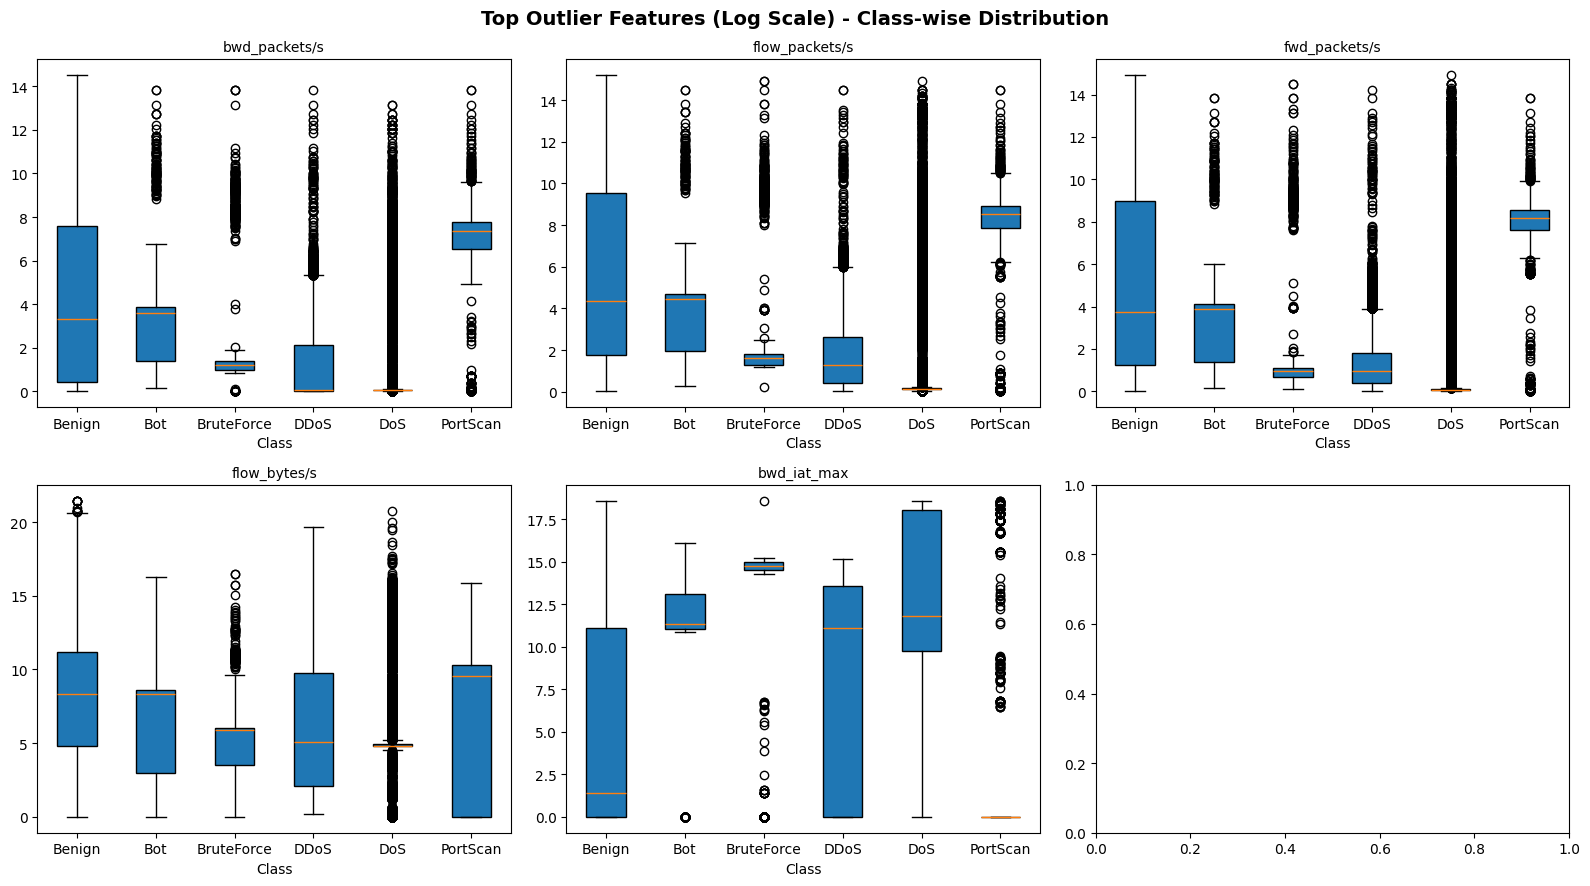

✅ Saved: final_outlier_analysis.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# LABEL_COLUMN = 'label'
# TOP_N = 6
# SAMPLE_SIZE = 1000000

# # ==============================
# # SAMPLE DATA
# # ==============================
# df_sample = df.sample(SAMPLE_SIZE, random_state=42)

# # ==============================
# # NUMERIC FEATURES
# # ==============================
# num_cols = df_sample.select_dtypes(include='number').columns.tolist()
# num_cols = [c for c in num_cols if c != LABEL_COLUMN]

# # ==============================
# # STEP 1: IQR OUTLIER TABLE
# # ==============================
# results = []

# for col in num_cols:
#     Q1 = df_sample[col].quantile(0.25)
#     Q3 = df_sample[col].quantile(0.75)
#     IQR = Q3 - Q1

#     if IQR == 0:
#         continue

#     lower = Q1 - 1.5 * IQR
#     upper = Q3 + 1.5 * IQR

#     out_count = ((df_sample[col] < lower) | (df_sample[col] > upper)).sum()

#     results.append((col, out_count))

# outlier_df = pd.DataFrame(results, columns=['Feature', 'Outliers',])
# outlier_df = outlier_df.sort_values(by='Outliers', ascending=False)

# ==============================
# STEP 2: TOP FEATURES
# ==============================
top_feats = outlier_df['Feature'].head(TOP_N).tolist()

print(" Top Features:", top_feats)

# ==============================
# STEP 3: LOG TRANSFORM (IMPORTANT)
# ==============================
df_plot = df_sample.copy()

for col in top_feats:
    df_plot[col] = np.log1p(df_plot[col])

# ==============================
# STEP 4: BOXPLOTS (CLASS-WISE)
# ==============================
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

classes = sorted(df_plot[LABEL_COLUMN].unique())

for i, feat in enumerate(top_feats):

    data_per_class = [
        df_plot[df_plot[LABEL_COLUMN] == cls][feat].dropna().values
        for cls in classes
    ]

    axes[i].boxplot(
        data_per_class,
        labels=[str(cls) for cls in classes],
        patch_artist=True
    )

    axes[i].set_title(feat, fontsize=10)
    axes[i].set_xlabel('Class')

fig.suptitle('Top Outlier Features (Log Scale) - Class-wise Distribution',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('final_outlier_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Saved: final_outlier_analysis.png")

##  EDA Step 8 — Constant & Low Variance Features

In [48]:
print('='*55)
print('  CONSTANT / LOW VARIANCE FEATURES')
print('='*55)

const_cols = [c for c in num_cols if df[c].nunique() == 1]
print(f'  Constant features (only 1 unique value): {len(const_cols)}')
if const_cols:
    for c in const_cols:
        print(f'    • {c} = {df[c].unique()[0]}')

# Low variance
low_var = []
for c in num_cols:
    if df[c].std() < 0.01 and c not in const_cols:
        low_var.append(c)
print(f'\n  Low variance features (std < 0.01): {len(low_var)}')
for c in low_var:
    print(f'    • {c}  std={df[c].std():.6f}')

  CONSTANT / LOW VARIANCE FEATURES
  Constant features (only 1 unique value): 8
    • bwd_psh_flags = 0
    • bwd_urg_flags = 0
    • fwd_avg_bytes/bulk = 0
    • fwd_avg_packets/bulk = 0
    • fwd_avg_bulk_rate = 0
    • bwd_avg_bytes/bulk = 0
    • bwd_avg_packets/bulk = 0
    • bwd_avg_bulk_rate = 0

  Low variance features (std < 0.01): 2
    • fwd_urg_flags  std=0.003265
    • cwe_flag_count  std=0.003265


##  EDA Step 9 — Summary Report

In [49]:
print('='*75)
print('  EDA SUMMARY REPORT')
print('='*75)

print(f'  Total rows           : {len(df):,}')
print(f'  Total columns        : {df.shape[1]}')
print(f'  Missing values       : {df.isnull().sum().sum():,}')
print(f'  Duplicate rows       : {df.duplicated().sum():,}')

# Negative value columns
neg_cols = (df[num_cols] < 0).sum()
neg_cols = neg_cols[neg_cols > 0]

print(f'  Negative value cols  : {len(neg_cols)}')

# Outlier columns (>5%)
print(f'  Outlier cols (>5%)   : {len(outlier_df[outlier_df["% Rows"] > 5])}')

print(f'  Constant cols        : {len(const_cols)}')

print('\n  CLASS QUALITY:')
print('  ' + '-'*60)

for _, row in dup_df.iterrows():
    quality = 'Good' if row['dup_pct'] < 30 else 'Check' if row['dup_pct'] < 70 else 'Bad'

    print(f'  Class {str(row["class"]):<12} | '
          f'{int(row["total"]):>10,} rows | '
          f'{row["dup_pct"]:>6.1f}% duplicate | '
          f'{quality}')

print('='*75)

  EDA SUMMARY REPORT
  Total rows           : 2,157,943
  Total columns        : 78
  Missing values       : 0
  Duplicate rows       : 64,753
  Negative value cols  : 12
  Outlier cols (>5%)   : 48
  Constant cols        : 8

  CLASS QUALITY:
  ------------------------------------------------------------
  Class Benign       |  1,823,641 rows |    3.6% duplicate | Good
  Class Bot          |      1,437 rows |    0.0% duplicate | Good
  Class BruteForce   |      9,150 rows |    0.0% duplicate | Good
  Class DDoS         |    128,014 rows |    0.0% duplicate | Good
  Class DoS          |    193,745 rows |    0.0% duplicate | Good
  Class PortScan     |      1,956 rows |    0.0% duplicate | Good


In [50]:
print(outlier_df.columns)

Index(['Feature', 'Outliers', '% Rows'], dtype='object')


---
#  Data Cleaning


##  Clean Step 1 — Duplicate Rows Remove

In [51]:
print(f'Before: {df.shape}')
df = df.drop_duplicates()
print(f'After : {df.shape}')
print(f'Removed: {df.duplicated().sum():,} duplicate rows')

Before: (2157943, 78)
After : (2093190, 78)
Removed: 0 duplicate rows


##  Clean Step 2 — Missing Values Handle

In [52]:
missing = df.isnull().sum()
missing = missing[missing > 0]

if len(missing) == 0:
    print(' no missing values  — skip!')
else:
    print(f'Missing values found: {missing}')
    df = df.dropna()
    print(f'After dropna: {df.shape}')

 no missing values  — skip!


##  Clean Step 3 — Negative Values Fix

In [53]:
num_cols = df.select_dtypes(include='number').columns.tolist()
num_cols = [c for c in num_cols if c != LABEL_COLUMN]

neg = (df[num_cols] < 0).sum()
neg_cols = neg[neg > 0].index.tolist()

if len(neg_cols) == 0:
    print(' no negative values — skip!')
else:
    print(f'Negative value columns ({len(neg_cols)}): {neg_cols}')
    # Option 1: clip to 0 (negative ko zero karo)
    for col in neg_cols:
        df[col] = df[col].clip(lower=0)
    print(f' Negative values clipped to 0')
    print(f'Verify: {(df[neg_cols] < 0).sum().sum()} negative values remaining')

Negative value columns (12): ['flow_duration', 'flow_bytes/s', 'flow_packets/s', 'flow_iat_mean', 'flow_iat_max', 'flow_iat_min', 'fwd_iat_min', 'fwd_header_length', 'bwd_header_length', 'init_fwd_win_bytes', 'init_bwd_win_bytes', 'fwd_seg_size_min']
 Negative values clipped to 0
Verify: 0 negative values remaining


##  Clean Step 4 — Constant Features Remove

In [54]:
const_cols = [c for c in num_cols if df[c].nunique() == 1]

if len(const_cols) == 0:
    print(' no constant features  — skip!')
else:
    print(f'Removing constant columns: {const_cols}')
    df = df.drop(columns=const_cols)
    print(f'Removed {len(const_cols)} constant columns')
    print(f'Shape after: {df.shape}')

Removing constant columns: ['bwd_psh_flags', 'bwd_urg_flags', 'fwd_avg_bytes/bulk', 'fwd_avg_packets/bulk', 'fwd_avg_bulk_rate', 'bwd_avg_bytes/bulk', 'bwd_avg_packets/bulk', 'bwd_avg_bulk_rate']
Removed 8 constant columns
Shape after: (2093190, 70)


##  Clean Step 5 — Outliers Handle (IQR method)

In [55]:
# IQR method se extreme outliers cap karo


num_cols = df.select_dtypes(include='number').columns.tolist()
num_cols = [c for c in num_cols if c != LABEL_COLUMN]

capped = 0
for col in num_cols:
    Q1  = df[col].quantile(0.01)
    Q99 = df[col].quantile(0.99)
    before = ((df[col] < Q1) | (df[col] > Q99)).sum()
    if before > 0:
        df[col] = df[col].clip(lower=Q1, upper=Q99)
        capped += 1

print(f' Outliers capped (1st-99th percentile) in {capped} columns')
print(f'Shape: {df.shape}')

 Outliers capped (1st-99th percentile) in 62 columns
Shape: (2093190, 70)


##  Clean Step 6 — Minority Class Quality Check

In [57]:
print('='*60)
print('        MINORITY CLASS QUALITY AFTER CLEANING')
print('='*60)

for cls in sorted(df[LABEL_COLUMN].unique()):
    subset = df[df[LABEL_COLUMN]==cls]
    total  = len(subset)
    unique = len(subset.drop_duplicates())
    pct    = total/len(df)*100
    dup    = total - unique

    print(f"""
Class {cls}
  → Total Rows   : {total:,}
  → Percentage   : {pct:.2f}%
  → Unique Rows  : {unique:,}
  → Duplicates   : {dup:,}
""")

print('='*60)

        MINORITY CLASS QUALITY AFTER CLEANING

Class Benign
  → Total Rows   : 1,758,888
  → Percentage   : 84.03%
  → Unique Rows  : 1,756,316
  → Duplicates   : 2,572


Class Bot
  → Total Rows   : 1,437
  → Percentage   : 0.07%
  → Unique Rows  : 1,437
  → Duplicates   : 0


Class BruteForce
  → Total Rows   : 9,150
  → Percentage   : 0.44%
  → Unique Rows  : 9,150
  → Duplicates   : 0


Class DDoS
  → Total Rows   : 128,014
  → Percentage   : 6.12%
  → Unique Rows  : 128,014
  → Duplicates   : 0


Class DoS
  → Total Rows   : 193,745
  → Percentage   : 9.26%
  → Unique Rows  : 193,730
  → Duplicates   : 15


Class PortScan
  → Total Rows   : 1,956
  → Percentage   : 0.09%
  → Unique Rows  : 1,956
  → Duplicates   : 0



##  Clean Step 7 — Save Clean Dataset

In [58]:
CLEAN_PATH = 'clean_numeric_dataset.parquet'
df.to_csv(CLEAN_PATH, index=False)

print('='*55)
print('  CLEANING COMPLETE')
print('='*55)
print(f'  Clean file saved : {CLEAN_PATH}')
print(f'  Final shape      : {df.shape}')
print(f'  Total rows       : {df.shape[0]:,}')
print(f'  Total columns    : {df.shape[1]}')
print()
print('  Final class distribution:')
for cls, cnt in df[LABEL_COLUMN].value_counts().sort_index().items():
    pct = cnt/len(df)*100
    print(f'    Class {cls} : {cnt:>10,}  ({pct:.2f}%)')
print('='*55)
print()


  CLEANING COMPLETE
  Clean file saved : clean_numeric_dataset.parquet
  Final shape      : (2093190, 70)
  Total rows       : 2,093,190
  Total columns    : 70

  Final class distribution:
    Class Benign :  1,758,888  (84.03%)
    Class Bot :      1,437  (0.07%)
    Class BruteForce :      9,150  (0.44%)
    Class DDoS :    128,014  (6.12%)
    Class DoS :    193,745  (9.26%)
    Class PortScan :      1,956  (0.09%)

